# Notebook 02 — Label Engineering
**Piecewise-linear RUL with censoring-aware treatment**

> The single most common mistake in RUL prediction is treating censored units as failures. This notebook shows exactly why that is wrong and how we handle it correctly.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from src.config import TRAIN_PATH, UNITS_PATH
from src.data_loader import load_and_validate_data, detect_sensor_columns
from src.label_engineer import RULLabelEngineer
from src.eda_utils import select_rul_max_empirically
print("Imports OK")


Imports OK


In [2]:
train_df, units_df = load_and_validate_data(TRAIN_PATH, UNITS_PATH)
sensor_cols, _ = detect_sensor_columns(train_df)


23:02:28 [data_loader] INFO: Loading training data…


23:02:28 [data_loader] INFO: =======================================================


23:02:28 [data_loader] INFO:   Units total    : 80


23:02:28 [data_loader] INFO:   Failed         : 72  |  Censored: 8


23:02:28 [data_loader] INFO:   Total rows     : 16,603


23:02:28 [data_loader] INFO:   Lifetime min   : 100  mean: 208  max: 339 cycles


23:02:28 [data_loader] INFO:   Missing values : 14,978  (4.51%)


23:02:28 [data_loader] INFO: =======================================================


23:02:28 [data_loader] INFO: Detected 15 sensor cols, 2 operational cols


## 1. Why Piecewise-Linear RUL?

Raw RUL starts at (e.g.) 350 for the first cycle of a 350-cycle pump.
Predicting 350 from early sensor readings is **impossible** — early healthy readings look the same regardless of eventual total life.

Solution: **cap RUL at RUL_MAX** (the degradation onset point).

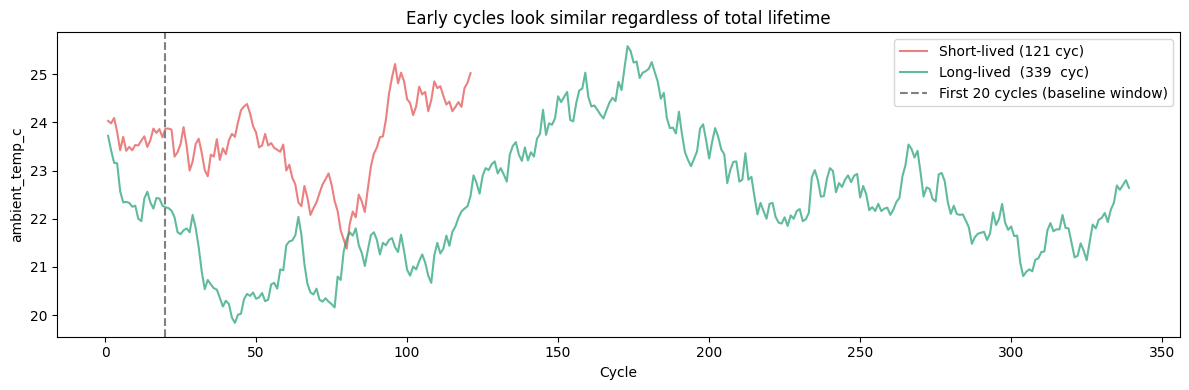

In [3]:
# Demonstrate: early cycles of short vs long-lived pumps look similar
failed_ids = units_df[units_df['event_flag']==1]['unit_id'].tolist()
lifetimes = {uid: train_df[train_df['unit_id']==uid]['cycle'].max()
             for uid in failed_ids}
lt_series = pd.Series(lifetimes).sort_values()

short_uid = lt_series.index[0]
long_uid  = lt_series.index[-1]
col = sensor_cols[0] if sensor_cols else 'cycle'

fig, ax = plt.subplots(figsize=(12, 4))
for uid, label, color in [(short_uid, f'Short-lived ({lt_series[short_uid]} cyc)', '#E24B4A'),
                            (long_uid,  f'Long-lived  ({lt_series[long_uid]}  cyc)', '#1D9E75')]:
    d = train_df[train_df['unit_id']==uid].sort_values('cycle')
    ax.plot(d['cycle'], d[col], alpha=0.7, label=label, color=color)
ax.set_xlabel('Cycle'); ax.set_ylabel(col)
ax.set_title('Early cycles look similar regardless of total lifetime')
ax.axvline(20, ls='--', color='gray', label='First 20 cycles (baseline window)')
ax.legend(); plt.tight_layout(); plt.show()


## 2. Auto-Select RUL_MAX

23:02:28 [label_engineer] INFO: RULLabelEngineer fitted | rul_max=50 | failed=72 | censored=8 | p90_lifetime=284


23:02:29 [label_engineer] INFO: Labels generated | labeled rows: 15,541 | excluded (censored): 1,062 | in degradation window: 3,600


23:02:29 [label_engineer] INFO: RULLabelEngineer fitted | rul_max=55 | failed=72 | censored=8 | p90_lifetime=284


23:02:29 [label_engineer] INFO: Labels generated | labeled rows: 15,541 | excluded (censored): 1,062 | in degradation window: 3,960


23:02:29 [label_engineer] INFO: RULLabelEngineer fitted | rul_max=60 | failed=72 | censored=8 | p90_lifetime=284


...

23:02:35 [label_engineer] INFO: RULLabelEngineer fitted | rul_max=195 | failed=72 | censored=8 | p90_lifetime=284


23:02:36 [label_engineer] INFO: Labels generated | labeled rows: 15,541 | excluded (censored): 1,062 | in degradation window: 13,048


23:02:36 [label_engineer] INFO: RULLabelEngineer fitted | rul_max=200 | failed=72 | censored=8 | p90_lifetime=284


23:02:36 [label_engineer] INFO: Labels generated | labeled rows: 15,541 | excluded (censored): 1,062 | in degradation window: 13,265


23:02:36 [eda_utils] INFO: Empirically selected RUL_MAX = 185 (mean |Spearman| = 0.3077)


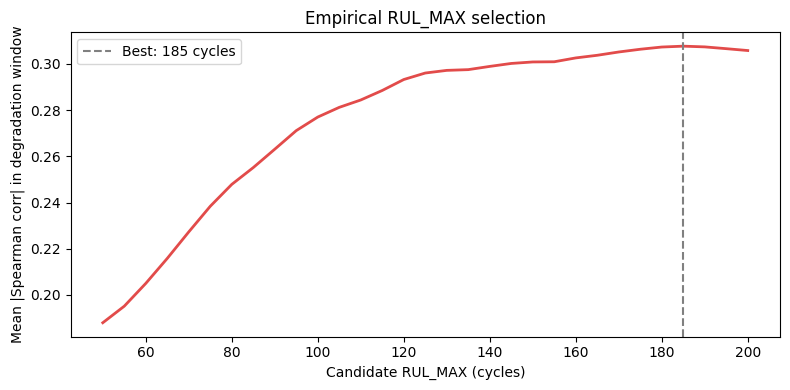

Selected RUL_MAX = 185


In [4]:
rul_max = select_rul_max_empirically(
    train_df, units_df, sensor_cols, plot=True
)
print(f"Selected RUL_MAX = {rul_max}")


## 3. Generate Labels — Correct Censoring Treatment

In [5]:
le = RULLabelEngineer(rul_max=rul_max, censoring_strategy='exclude')
df_labeled = le.fit_transform(train_df, units_df)
df_labeled.head(5)


23:02:36 [label_engineer] INFO: RULLabelEngineer fitted | rul_max=185 | failed=72 | censored=8 | p90_lifetime=284


23:02:36 [label_engineer] INFO: Labels generated | labeled rows: 15,541 | excluded (censored): 1,062 | in degradation window: 12,585


,unit_id,cycle,timestamp,op_regime,op_setpoint_flow,ambient_temp_c,vibration_rms_mms,bearing_temp_c,casing_temp_c,motor_current_a,...,power_kw,oil_particle_count,coolant_flow_lpm,ambient_humidity_pct,pump_speed_rpm,gearbox_temp_c,raw_rul,rul,sample_weight,in_degradation_window
0,PUMP_001,1,2024-12-01 00:00:00,0,87.199997,24.209999,1.991,52.619999,50.500000,38.099998,...,23.750000,NaN,12.006,70.300003,2956.899902,37.810001,291.0,185.0,1.0,False
1,PUMP_001,2,2024-12-01 01:00:00,0,84.720001,24.129999,1.912,50.000000,48.009998,38.299999,...,23.740000,NaN,11.980,57.000000,2949.000000,37.410000,290.0,185.0,1.0,False
2,PUMP_001,3,2024-12-01 02:00:00,0,84.230003,24.150000,1.379,52.509998,47.740002,38.700001,...,24.049999,NaN,11.977,55.400002,2958.199951,36.900002,289.0,185.0,1.0,False
3,PUMP_001,4,2024-12-01 03:00:00,0,84.370003,23.980000,1.935,52.130001,49.009998,37.270000,...,23.330000,NaN,11.998,72.199997,2958.699951,36.880001,288.0,185.0,1.0,False
4,PUMP_001,5,2024-12-01 04:00:00,0,85.959999,24.219999,1.542,51.810001,50.580002,38.790001,...,24.799999,NaN,12.023,51.599998,2955.100098,36.700001,287.0,185.0,1.0,False


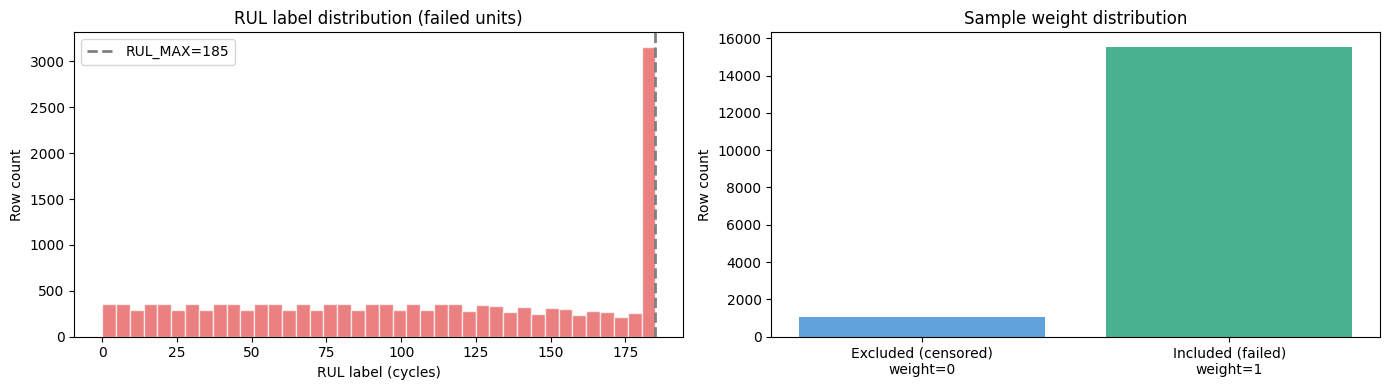

Labeled rows  : 15,541
Excluded rows : 1,062


In [6]:
# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: RUL distribution (failed units only)
failed_labels = df_labeled[(df_labeled['sample_weight'] > 0) & df_labeled['rul'].notna()]
axes[0].hist(failed_labels['rul'], bins=40, color='#E24B4A', alpha=0.7, edgecolor='white')
axes[0].axvline(rul_max, ls='--', color='gray', lw=2, label=f'RUL_MAX={rul_max}')
axes[0].set_xlabel('RUL label (cycles)'); axes[0].set_ylabel('Row count')
axes[0].set_title('RUL label distribution (failed units)'); axes[0].legend()

# Right: sample_weight distribution
weights = df_labeled['sample_weight'].value_counts()
axes[1].bar(['Excluded (censored)\nweight=0', 'Included (failed)\nweight=1'],
            [weights.get(0.0, 0), weights.get(1.0, 0)],
            color=['#3B8BD4', '#1D9E75'], alpha=0.8)
axes[1].set_ylabel('Row count')
axes[1].set_title('Sample weight distribution')

plt.tight_layout(); plt.show()
print(f"Labeled rows  : {(df_labeled['sample_weight']>0).sum():,}")
print(f"Excluded rows : {(df_labeled['sample_weight']==0).sum():,}")

## 4. Show the Danger: Wrong Labels

23:02:37 [label_engineer] INFO: RULLabelEngineer fitted | rul_max=185 | failed=72 | censored=8 | p90_lifetime=284


23:02:37 [label_engineer] INFO: Labels generated | labeled rows: 15,541 | excluded (censored): 1,062 | in degradation window: 12,855


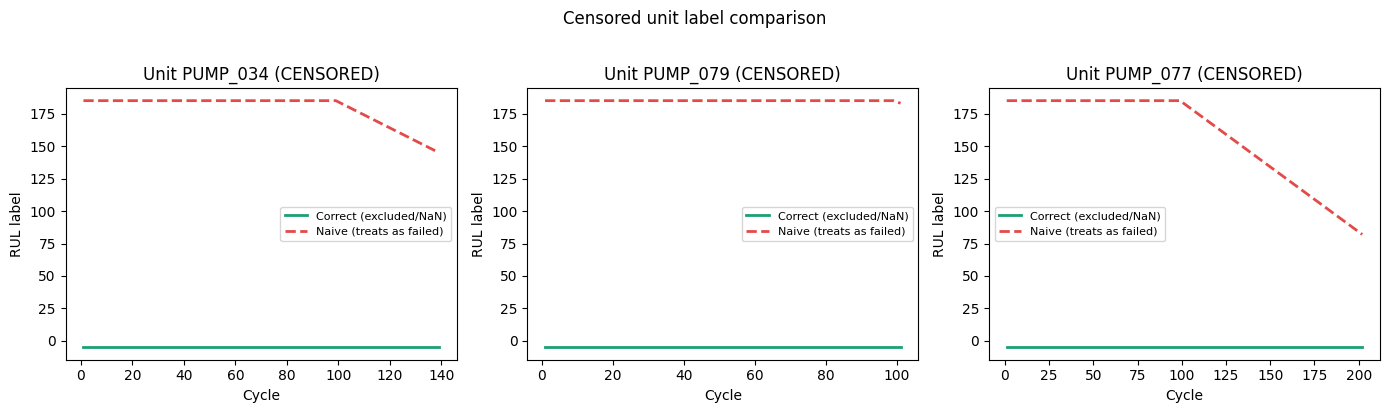

Naive labels near last cycle: [84. 83. 82.]
These are NOT failures — assigning RUL=0 here is WRONG.


In [7]:
# Demonstrate what happens if we naively treat censored as failed
naive_le = RULLabelEngineer(rul_max=rul_max, censoring_strategy='conservative_bound')
df_naive = naive_le.fit_transform(train_df, units_df)

censored_ids = list(le.censored_ids_)[:3]
fig, axes = plt.subplots(1, len(censored_ids), figsize=(14, 4))
for ax, uid in zip(axes, censored_ids):
    unit_correct = df_labeled[df_labeled['unit_id']==uid].sort_values('cycle')
    unit_naive   = df_naive[df_naive['unit_id']==uid].sort_values('cycle')
    ax.plot(unit_correct['cycle'], unit_correct['rul'].fillna(-5),
            label='Correct (excluded/NaN)', color='#1D9E75', lw=2)
    ax.plot(unit_naive['cycle'], unit_naive['rul'],
            label='Naive (treats as failed)', color='#E24B4A', lw=2, ls='--')
    ax.set_title(f'Unit {uid} (CENSORED)')
    ax.set_xlabel('Cycle'); ax.set_ylabel('RUL label')
    ax.legend(fontsize=8)
plt.suptitle('Censored unit label comparison', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()
print("Naive labels near last cycle:", unit_naive['rul'].tail(3).values)
print("These are NOT failures — assigning RUL=0 here is WRONG.")


## 5. Degradation Window Analysis

In [8]:
dw = df_labeled[df_labeled['in_degradation_window'] & df_labeled['rul'].notna()]
print(f"Degradation window rows : {len(dw):,}")
print(f"Fraction of total       : {len(dw)/len(df_labeled)*100:.1f}%")
print(f"Unique units in window  : {dw['unit_id'].nunique()}")
print(f"RUL range in window     : [{dw['rul'].min():.0f}, {dw['rul'].max():.0f}]")


Degradation window rows : 12,585
Fraction of total       : 75.8%
Unique units in window  : 72
RUL range in window     : [0, 184]


## Summary

| Item | Value |
|---|---|
| RUL_MAX | Selected empirically |
| Labeling strategy | Piecewise linear: cap at RUL_MAX |
| Censored treatment | Excluded (sample_weight=0) |
| Labeled rows | see output above |
| Excluded rows | see output above |